# Handwritten Digit Recognition Using Convolutional Neural Network

This project builds a Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset.

The goal is to practice deep learning image classification and create an interviewer-friendly machine learning project.

The project includes:
- Loading and exploring image data
- Preprocessing images for neural network training
- Building a CNN model using TensorFlow/Keras
- Training and validating the model
- Evaluating model performance
- Visualizing predictions
- Reviewing misclassified images

In [1]:
#pip install --upgrade pip

In [2]:
#pip install tensorflow

# Step 1: Import Libraries

In [3]:
# Handles numerical arrays
import numpy as np

# Displays images and charts
import matplotlib.pyplot as plt

# Builds and trains the neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Show precision, recall, and F1-score
from sklearn.metrics import classification_report, confusion_matrix

# Makes the confusion matrix easier to read
import seaborn as sns

# Step 2: Load the MNIST Dataset

In [5]:
# Load MNIST handwritten digit dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


### Explanation:
- 60000 training images
- 10000 testing images
- Each image is 28 x 28 pixels

# Step 3: Display Sample Images

In [6]:
print("Unique training labels:", np.unique(y_train))
print("Unique testing labels:", np.unique(y_test))

Unique training labels: [0 1 2 3 4 5 6 7 8 9]
Unique testing labels: [0 1 2 3 4 5 6 7 8 9]


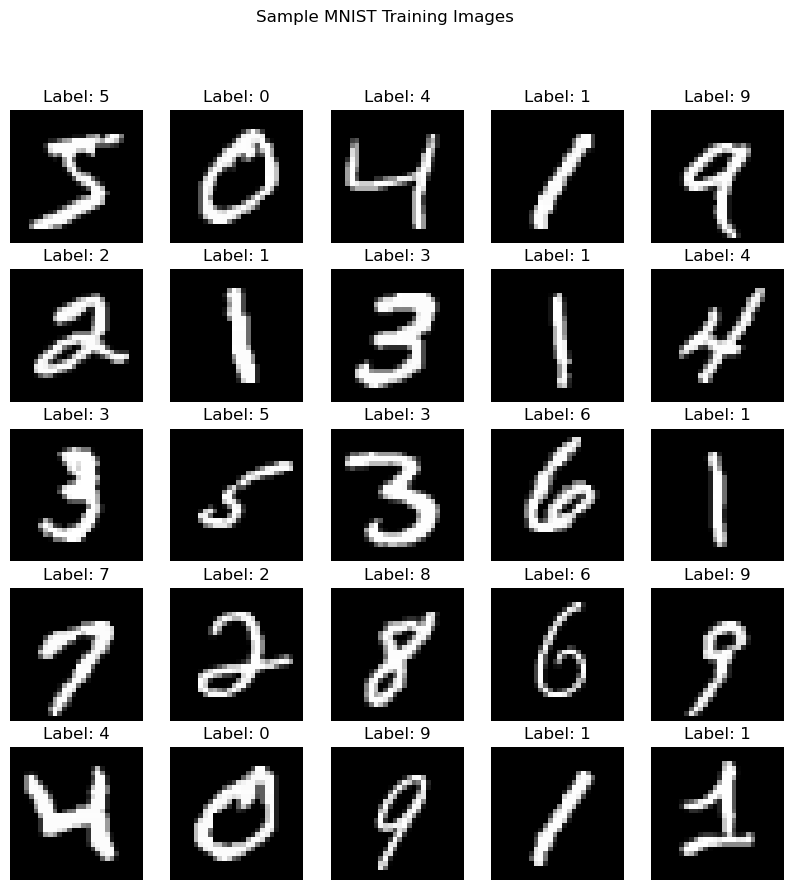

In [25]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {class_names[y_train[i]]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Training Images")
plt.show()

### Explanation:

This step displays sample images from the MNIST training dataset. 
The labels confirm that the dataset contains handwritten digits from 0 to 9.

The images are displayed in grayscale because each MNIST image has one pixel intensity channel instead of three RGB color channels.

# Step 4: Normalize the Image Data

In [24]:
# Check the shape and pixel value range before normalization
# Each MNIST image is 28 x 28 pixels
print("One image shape:", x_train[0].shape)

# Before normalization, pixel values are usually between 0 and 255
# 0 represents black and 255 represents white
print("Pixel value range:", x_train[0].min(), "to", x_train[0].max())

One image shape: (28, 28)
Pixel value range: 0.0 to 1.0


In [22]:
# Normalize pixel values from the range 0-255 to the range 0-1
# This helps the neural network train more efficiently
# Dividing by 255.0 converts the pixel values into smaller decimal values
x_train = x_train / 255.0
x_test = x_test / 255.0

In [23]:
print("Training data minimum pixel value:", x_train.min())
print("Training data maximum pixel value:", x_train.max())

print("Testing data minimum pixel value:", x_test.min())
print("Testing data maximum pixel value:", x_test.max())

Training data minimum pixel value: 0.0
Training data maximum pixel value: 1.0
Testing data minimum pixel value: 0.0
Testing data maximum pixel value: 1.0


### Explanation:

MNIST images are grayscale images, and each image has a shape of 28 × 28 pixels.

The original pixel values range from 0 to 255, where 0 represents black and 255 represents white. 
After normalization, the pixel values are scaled to the range 0 to 1.

This helps the neural network train more efficiently because the input values become smaller and more consistent.


# Step 5: Reshape Images for CNN Input

In [26]:
# Add one channel dimension for grayscale images

# CNN expects image input format: (number of images, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1) 
x_test = x_test.reshape(-1, 28, 28, 1)

print("New training shape:", x_train.shape)
print("New testing shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)


### Explanation:
After reshaping, the training images have the shape `(60000, 28, 28, 1)` and the testing images have the shape `(10000, 28, 28, 1)`.

The final `1` represents the single grayscale channel. This is required because CNN models expect image input in the format `(number of images, height, width, channels)`.

### Why Use a CNN?

A Convolutional Neural Network (CNN) is used because the MNIST dataset contains image data. Each image is made of pixels, and the position of nearby pixels is important for recognizing handwritten digits.

CNNs are effective for image classification because they can detect visual patterns such as edges, curves, strokes, and digit shapes. Convolutional layers learn these patterns from the image, while pooling layers reduce the feature size and keep the most important information.

For this project, a CNN is more suitable than a basic fully connected neural network because it preserves the spatial structure of the image and learns features directly from the pixel layout.

# Step 6: Build CNN Model

In [29]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

### Explanation:

- `Input`: Defines the input image shape as 28 × 28 pixels with 1 grayscale channel.
- `Conv2D`: Extracts visual patterns such as edges, curves, and digit shapes.
- `MaxPooling2D`: Reduces the image feature size while keeping the most important information.
- `Flatten`: Converts the 2D feature maps into a 1D vector.
- `Dense`: Learns patterns for classifying the digit.
- `Dropout`: Randomly disables some neurons during training to reduce overfitting.
- `Softmax`: Produces probability scores for the 10 digit classes from 0 to 9.

### Model Architecture Explanation:

This CNN model is designed for handwritten digit image classification. The input layer receives 28 × 28 grayscale images.

The convolutional layers extract visual features such as edges, curves, strokes, and digit shapes. The max pooling layers reduce the size of the feature maps while keeping the most important information.

After feature extraction, the flatten layer converts the 2D feature maps into a 1D vector. The dense layer learns classification patterns from these extracted features. Dropout is used to reduce overfitting by randomly disabling some neurons during training.

The final dense layer has 10 output neurons because there are 10 digit classes from 0 to 9. The softmax activation function converts the output into probability scores, and the class with the highest probability becomes the final predicted digit.

# Step 7: Compile the Model

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape              ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                  │ (None, 26, 26, 32)        │            320 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ max_pooling2d_2 (MaxPooling2D)     │ (None, 13, 13, 32)        │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ conv2d_3 (Conv2D)                  │ (None, 11, 11, 64)        │         18,496 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ max_pooling2d_3 (MaxPooling2D)     │ (None, 5, 5, 64)          │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ flatten_1 (Flatten)                │ (None, 1600)              │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_2 (Dense)                    │ (None, 64)                │        102,464 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout_1 (Dropout)                │ (None, 64)                │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_3 (Dense)                    │ (None, 10)                │            650 │
└────────────────────────────────────┴───────────────────────────┴────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### Explanation:

- `adam`: Optimizer used to update the model weights during training.
- `sparse_categorical_crossentropy`: Loss function used for multi-class classification when the labels are stored as integers from 0 to 9.
- `accuracy`: Evaluation metric that measures the percentage of correctly classified images.
- `model.summary()`: Displays each layer, output shape, and the number of trainable parameters in the CNN model.

# Step 8: Train the Model

In [31]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.9241 - loss: 0.2480 - val_accuracy: 0.9790 - val_loss: 0.0734
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.9747 - loss: 0.0866 - val_accuracy: 0.9862 - val_loss: 0.0485
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9812 - loss: 0.0620 - val_accuracy: 0.9892 - val_loss: 0.0402
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.9839 - loss: 0.0532 - val_accuracy: 0.9893 - val_loss: 0.0390
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.9873 - loss: 0.0411 - val_accuracy: 0.9905 - val_loss: 0.0348


### Explanation:

- `epochs=5`: Model sees the training data 5 times.
- `batch_size=64`: Model updates weights after every 64 samples
- `validation_split=0.1`: Uses 10% of training data for validation

### Results

After 5 epochs, the model achieved high training and validation accuracy. 
The training accuracy reached approximately 98% to 99%, and the validation accuracy reached approximately 99%.

The training loss and validation loss both decreased across the epochs, which shows that the model was learning effectively.

### Training Result Observation:

After 5 epochs, the CNN model achieved strong training and validation performance. 
The training accuracy reached about 98.73%, while the validation accuracy reached about 99.05%.

The training loss and validation loss both decreased across the epochs, which shows that the model was learning effectively. 
There is no clear sign of overfitting because the validation accuracy remained close to the training accuracy.

# Step 9: Plot Training Accuracy and Loss

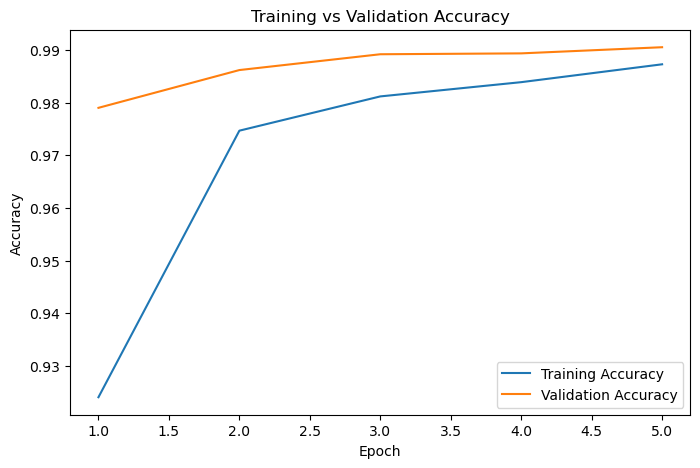

In [34]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

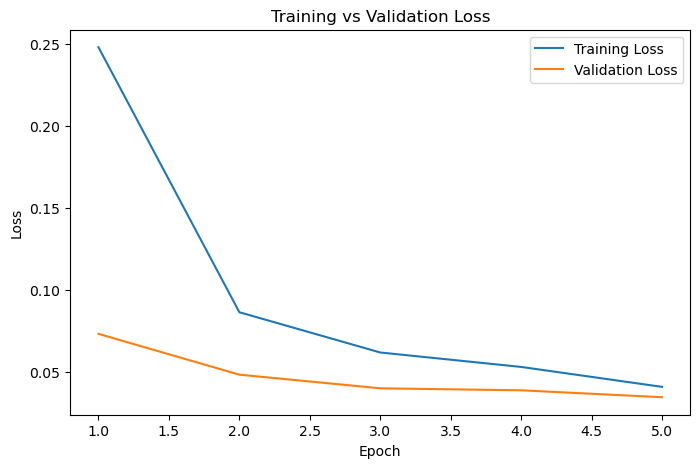

In [35]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

### Training Curve Observation

The training and validation accuracy both increased across the 5 epochs, showing that the CNN model learned useful digit patterns from the image data.

The training and validation loss both decreased, meaning the model's prediction error became smaller over time.

There is no clear sign of overfitting because the validation accuracy stayed close to the training accuracy, and the validation loss did not increase.

# Step 10: Evaluate the Model on Test Data

In [36]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9890 - loss: 0.0335
Test Loss: 0.03354325518012047
Test Accuracy: 0.9890000224113464


### Test Evaluation Observation:

The CNN model achieved a test accuracy of approximately 98.90% and a test loss of approximately 0.0335.

This means the model performed very well on unseen test images. Since the test accuracy is close to the validation accuracy, the model appears to generalize well and does not show a clear sign of overfitting.

# Step 11: Generate Predictions

In [40]:
# Generate probability scores for each test image
y_pred_prob = model.predict(x_test)

# Convert probability scores into final predicted labels
# np.argmax selects the digit class with the highest probability
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [41]:
print("Prediction probabilities for first test image:")
print(y_pred_prob[0])

print("Predicted label:", y_pred[0]) # Final predicted digit label
print("Actual label:", y_test[0]) # True digit label from the dataset

Prediction probabilities for first test image:
[4.2256396e-10 1.0455198e-07 1.2975718e-07 1.5888216e-06 1.5880280e-10
 2.6991649e-09 3.5334680e-15 9.9999642e-01 3.9607140e-09 1.7716594e-06]
Predicted label: 7
Actual label: 7


### Explanation:

The model outputs probability scores for each digit class from 0 to 9.

`np.argmax()` selects the class with the highest probability and converts the probability output into the final predicted digit label.

# Step 12: Classification Report

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Explanation:

- `Precision`: When the model predicts a digit, how often it is correct
- `Recall`: How many real examples of that digit the model finds
- `F1-score`: Balance between precision and recall
- `Support`: Number of test samples for each digit

### Classification Report Observation

The classification report shows strong performance across all digit classes. 
Most digits have precision, recall, and F1-score values around 0.98 to 1.00.

The overall accuracy is approximately 99%, which means the model correctly classified most of the 10,000 test images.

# Step 13: Confusion Matrix

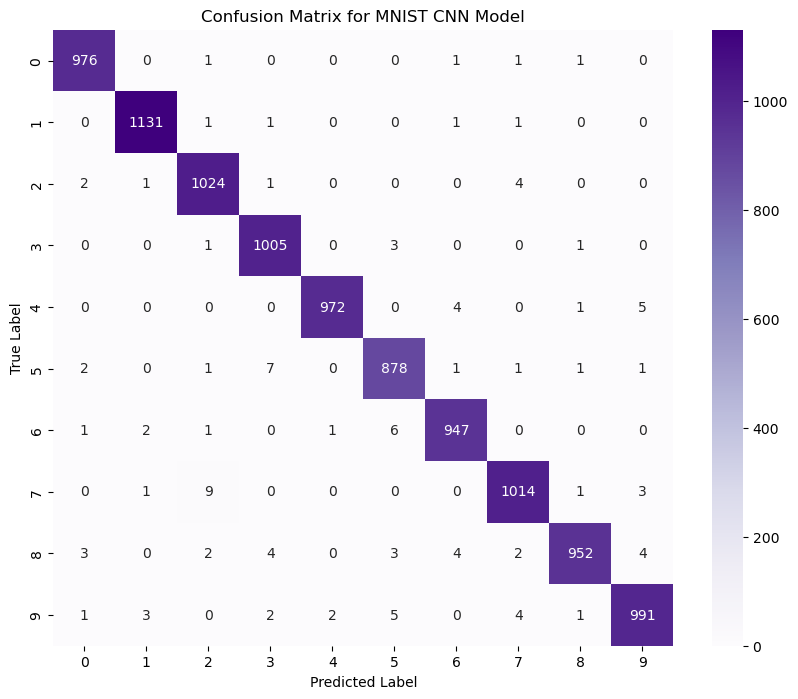

In [46]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for MNIST CNN Model")
plt.show()

### Confusion Matrix Observation

The confusion matrix shows that most predictions are on the main diagonal, which means the model correctly classified most handwritten digits.

Only a small number of images were misclassified. For example, some digits such as 5, 6, and 7 were occasionally confused with visually similar digits.

Overall, the confusion matrix supports the classification report result and shows that the CNN model performs well on the MNIST test dataset.

# Step 14: Visualize Sample Model Predictions

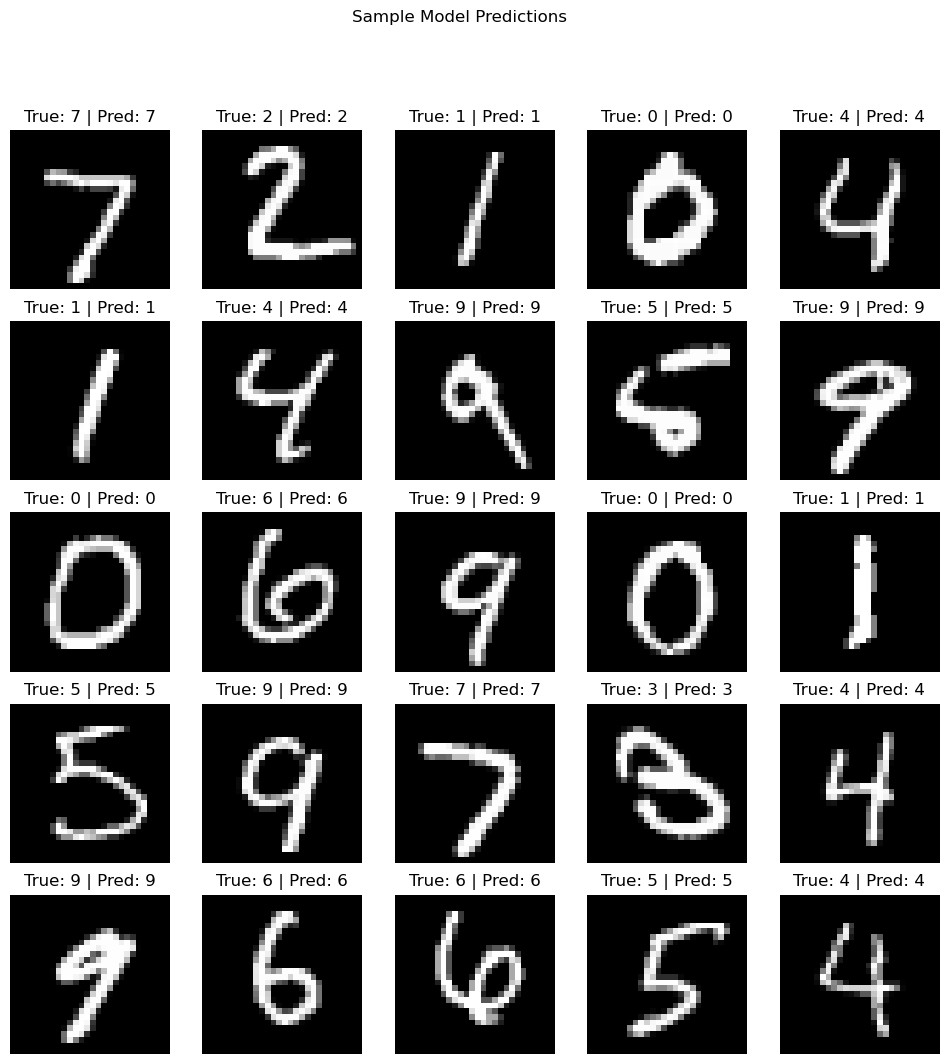

In [49]:
plt.figure(figsize=(12, 12))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[i]} | Pred: {y_pred[i]}")
    plt.axis("off")

plt.suptitle("Sample Model Predictions")
plt.show()

### Prediction Visualization Observation

This visualization shows sample test images with their true labels and predicted labels.

For these examples, the predicted labels match the true labels, which means the CNN correctly classified these handwritten digits.

# Step 15: Visualize Misclassified Images

Total test images: 10000
Correct predictions: 9890
Incorrect predictions: 110


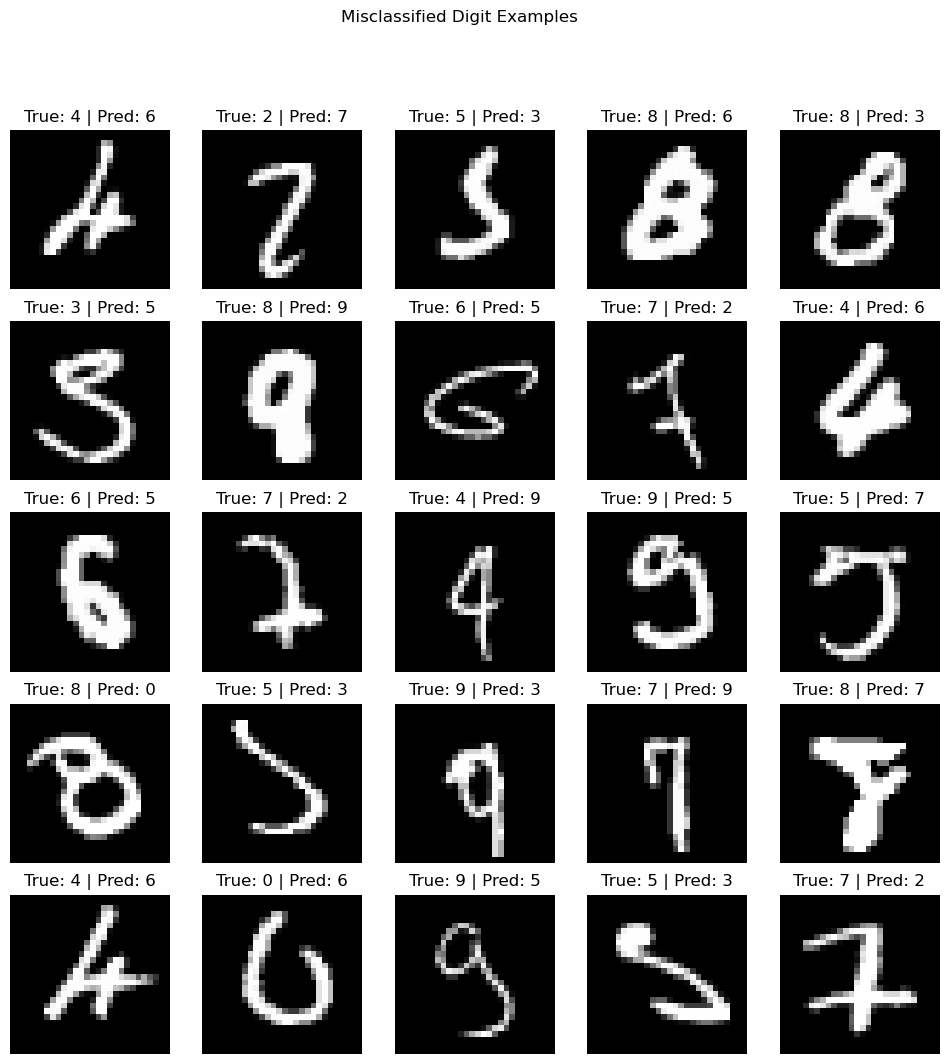

In [52]:
incorrect_indices = np.where(y_test != y_pred)[0]

print("Total test images:", len(y_test))
print("Correct predictions:", len(y_test) - len(incorrect_indices))
print("Incorrect predictions:", len(incorrect_indices))

plt.figure(figsize=(12, 12))

for i, index in enumerate(incorrect_indices[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[index]} | Pred: {y_pred[index]}")
    plt.axis("off")

plt.suptitle("Misclassified Digit Examples")
plt.show()

### Misclassified Image Observation

This section shows examples where the CNN model made incorrect predictions.

Many of the misclassified digits are visually ambiguous. For example, some handwritten 5s may look similar to 3s, some 7s may look similar to 2s, and some 4s may look similar to 6s or 9s.

Reviewing misclassified images helps identify the model’s limitations and understand which digit shapes are harder for the CNN to classify.

# Conclusion

This project built a CNN model to classify handwritten digits from the MNIST dataset.

The model achieved approximately 99% accuracy on the test dataset, showing strong performance on unseen handwritten digit images.

The classification report and confusion matrix showed that the model performed well across all digit classes from 0 to 9. 
Most errors occurred when handwritten digits had similar or unclear shapes, such as 5 and 3, 7 and 2, or 4 and 9.

Overall, this project helped me practice image preprocessing, CNN model building, model evaluation, prediction visualization, and error analysis using TensorFlow/Keras.